# Modeling Atmospheric Oxygen Dynamics on Early Earth 

## Overview

This notebook implements a dynamical model to study the rise of atmospheric oxygen on early Earth. The focus is on interactions between cyanobacterial biomass, oxygen accumulation, and reduced geological reservoirs.

## Model Assumption 

- Cyanobacteria follow logistic growth.
- Oxygen production is proportional to cyanobacteria biomass. 
- Oxidation of reduced materials depends on both oxygen concentration and reduced reservoir.
- Volcanic input replenishes the reduced reservoir at a constant rate.
- Other geological processes (sedimentation, tectonics) are not explicitly modeled.

## Mathematical Framework 
The model tracks three state variables B, O, R:

**dB/dt = rB (1-B/K)** 

**dO/dt = αB - γOR** 

**dR/dt = V - γOR**

### Parameter Definitions

- r: intrinsic growth rate of cyanobacteria
- K: environmental carrying capacity
- α: oxygen production rate per biomass
- γ: oxidation reaction rate constant
- V: volcanic flux of reduced materials

In [11]:
## import necessary Libraries

import numpy as np 
import matplotlib.pyplot as plt # differential equation solver
from scipy.integrate import solve_ivp 

In [12]:
## Parameter values
# cyanobacteria growth parameter
r = 0.1       # intrinsic growth rate
K = 1.0       # Carrying capacity

α = 0.05      # Oxygen production rate
γ = 0.01      # Oxidation rate constant

V = 0.005     # Volcanic flux

In [13]:
# Initial conditions
B0 = 0.01     # Initial cyanobacteria biomass
O0 = 0.0      # Initial oxygen concentration
R0 = 1.0      # Initial reduced reservoir
Y0 = [B0, O0, R0]

In [14]:
# time span for simulation

t_span = (0, 1000)  
t_eval = np.linspace(0,100,1000) # time points for evaluation

## Numerical Integration

In [16]:
def oxygen_model(t, Y, r, K, α, γ, V):

    B, O, R = Y

    dBdt = r*B*(1 - B/K)   #cyanobacteria logistic growth 
    dOdt = α*B - γ*O*R      #oxygen dynamics
    dRdt = V - γ*O*R       # Reduced reservior dynamics

    return [dBdt, dOdt, dRdt]

# solve the system
sol = solve_ivp(oxygen_model, 
                t_span, 
                Y0, 
                t_eval=t_eval,
                args= (r, K, α, γ, V)
               )

In [17]:
B= sol.y[0] 
O= sol.y[1] 
R= sol.y[2]

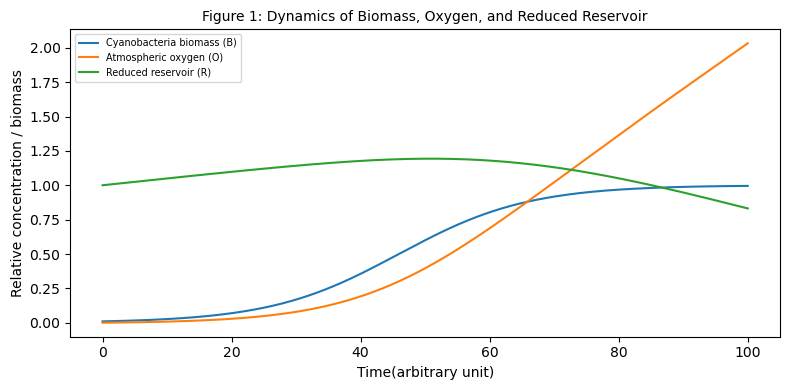

In [18]:
# system Dynamic plot 

plt.figure(figsize=(8,4))

plt.plot(t_eval, B, label="Cyanobacteria biomass (B)")
plt.plot(t_eval, O, label="Atmospheric oxygen (O)")
plt.plot(t_eval, R, label="Reduced reservoir (R)")

plt.xlabel("Time(arbitrary unit)")
plt.ylabel("Relative concentration / biomass")
plt.title("Figure 1: Dynamics of Biomass, Oxygen, and Reduced Reservoir", fontsize= 10)

plt.legend(fontsize= 'x-small')

plt.tight_layout()
plt.show()

The plot shows cyanobacterial biomass (B) growing logistically to its carrying capacity. Atmospheric oxygen (O) is initially held near zero by the reduced reservoir (R) until biological Oxygen production permanently exceeds the geological sink, triggering a rapid, non-linear rise in atmospheric oxygen.

## Phase Plot (R vs O)

The inverse correlation between atmospheric oxygen (O) and the reduced reservoir (R).

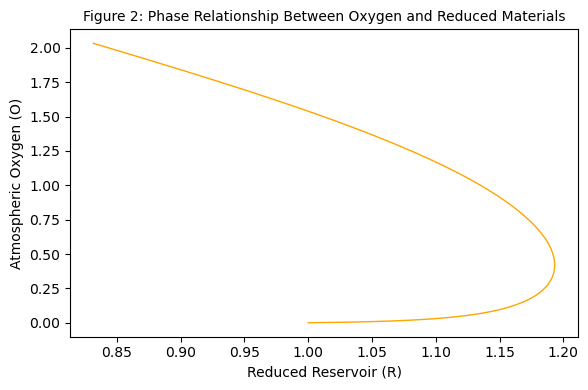

In [21]:
plt.figure(figsize=(6,4))

plt.plot(R, O, color= 'orange', linewidth=1)

plt.xlabel("Reduced Reservoir (R)")
plt.ylabel("Atmospheric Oxygen (O)")
plt.title("Figure 2: Phase Relationship Between Oxygen and Reduced Materials", fontsize=10)


plt.tight_layout()
plt.show()

The phase relationship plot between O and R shows the non-linear shift of the system. The trajectory shows a long horizontal "loading" phase where the reduced reservoir increases due to volcanic input while oxygen is suppressed. The characteristic "hook" in the curve identifies the exact transition point where biological oxygen production permanently surpasses the geological sink, forcing the system into a new, oxygenated steady state.

## Sensitivity to Volcanic Flux (V)

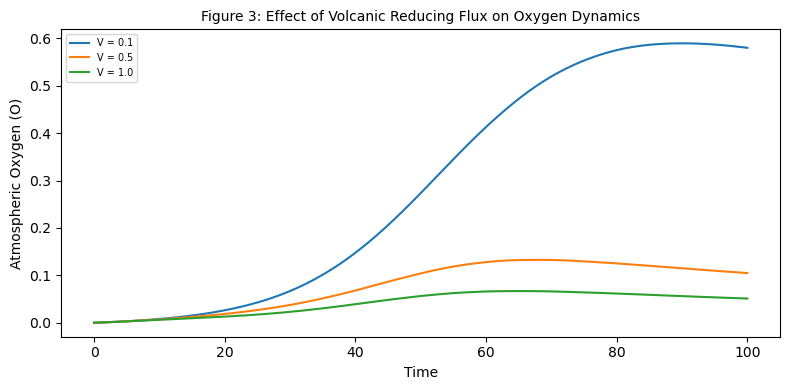

In [24]:
V_values = [0.1, 0.5, 1.0]

plt.figure(figsize=(8,4))

for V_test in V_values:
    
    sol = solve_ivp(
        oxygen_model,
        t_span,
        Y0,
        t_eval=t_eval,
        args=(r, K, α, γ, V_test))
    
    dO = sol.y[1]
    
    plt.plot(t_eval,  dO, label=f"V = {V_test}")

plt.xlabel("Time")
plt.ylabel("Atmospheric Oxygen (O)")
plt.title("Figure 3: Effect of Volcanic Reducing Flux on Oxygen Dynamics", fontsize=10)

plt.legend(fontsize='x-small')

plt.tight_layout()
plt.savefig('plot.png', dpi=300)
plt.show()

The plot shows how changes in volcanic reducing flux (V) control oxygenation. Higher outgassing strengthens the chemical sink and suppresses atmospheric O even after biomass reaches maturity. Conversely, lower flux values allow for an earlier and more dramatic oxygenation event.

# Result 

The simulation (Fig 1) shows a clear temporal sequence in the dynamics of biomass (B), atmospheric oxygen (O), and the reduced reservoir (R).

Initially, cyanobacterial biomass *B* follows a characteristic sigmoidal (logistic) growth curve as it gradually approaches its carrying capacity *K* **(Phase I: Biomass Expansion)**. During this early phase, atmospheric oxygen *O* remains near zero because the oxygen produced is rapidly consumed by the reduced reservoir *R*, which buffers the system **(Phase II: Sink-Limited Oxygen)**.

However, as biomass continues to increase, oxygen production eventually exceeds the reducing capacity of *R*. Once *B* crosses a critical threshold, the reduced reservoir becomes rapidly depleted and atmospheric oxygen rises nonlinearly **(Phase III: The Tipping Point)**. This rapid transition represents the simulated onset of the Great Oxidation Event, shifting the system from an anoxic to a more oxygenated state.


# Discussion

The model effectively captures the tipping-point behavior often associated with the Great Oxidation Event: oxygenation is a non-linear outcome of the balance between biological Oxygen production and geological reductant supply.

The delay between the rise of Cyanobacterial biomass *(B)* and the increase in atmospheric oxygen *(O)* reflects the role of geological sinks in initially buffering the atmosphere against oxygen accumulation. During this phase, most of the oxygen produced by photosynthesis is consumed through oxidation reactions with reduced materials. This confirms that an active biological source alone is insufficient for persistent oxygenation when geological sinks are strong.

Gradual depletion of *R* via the *γOR* oxidation reaction reduces the system’s ability to remove oxygen. Once oxygen production surpasses this sink capacity, atmospheric oxygen begins to rise rapidly. Sensitivity analysis indicates that volcanic flux *(V)* modulates the rate and timing of oxygen accumulation: elevated volcanic reducing fluxes strengthen the chemical sink and can delay Oxygenation even in the presence of mature biomass. This supports the hypothesis that the timing of the GOE may not have depended solely on the biological evolution of Cyanobacteria, but also on the long-term cooling of Earth's mantle and the subsequent decline of reducing volcanic gases (Holland, 2006; Lyons et al., 2014).